In [1]:
%matplotlib widget
import torch
import warnings
import os
import copy
import subprocess
import shlex
import matplotlib.pyplot as plt
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm
from torch.profiler import profile,  ProfilerActivity

os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

from sphMath.sampling import buildDomainDescription
from sphMath.modules.adaptiveSmoothingASPH import n_h_to_nH
from sphMath.plotting import visualizeParticles, updatePlot
from sphMath.integration import getIntegrator
from sphMath.util import volumeToSupport
from sphMath.boundary import sampleDomainSDF
from sphMath.kernels import Kernel_Scale
from sphMath.sdf import getSDF, sdfFunctions, operatorDict, sampleSDF
from sphMath.regions import buildRegion, filterRegion, plotRegions
from sphMath.modules.timestep import computeTimestep
from sphMath.schemes.initializers import initializeSimulation, updateBodyParticles
from sphMath.schemes.deltaSPH import deltaPlusSPHScheme, DeltaPlusSPHSystem
from sphMath.schema import getSimulationScheme
from sphMath.enums import *
from exampleUtil import setupExampleSimulation, runSimulation, postProcess
from sphMath.sampling import sampleDivergenceFreeNoise
import math

In [41]:
simulationName = 'Oscillating Droplet'
exportName = '04_oscillatingDroplet'
R = 1
A = 1
B = 1
T = 4.827 * A

L = 2 *3 * R

nx = 192*4
dx = L / nx
targetDt = 0.00025
rho0 = 1
freeSurface = True
band = 0
fps = 50
timeLimit = T

kernel = KernelType.Wendland4
scheme = SimulationScheme.DeltaSPH
integrationScheme = IntegrationSchemeType.symplecticEuler

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float64
targetNeighbors = n_h_to_nH(4, 2)
c_s = 0.3 * volumeToSupport(dx**2, targetNeighbors, 2) / Kernel_Scale(kernel, 2) / targetDt
exportInterval = 1 / fps
plotInterval = int(math.ceil(exportInterval / targetDt))
timesteps = int(timeLimit / targetDt)
print(c_s)

17.271244667215353


In [42]:
dim = 2
CFL = 0.3

domain = buildDomainDescription(l = L + dx * (band) * 2, dim = dim, periodic = True, device = device, dtype = dtype)
interiorDomain = buildDomainDescription(l = L, dim = dim, periodic = False, device = device, dtype = dtype)
wrappedKernel = kernel

simulator, SimulationSystem, config, integrator = getSimulationScheme(
     scheme, kernel, integrationScheme, 
     1.0, targetNeighbors, domain)
integrationScheme = getIntegrator(integrationScheme)

config['particle'] = {
    'nx': nx + 2 * band,
    'dx': L/nx,
    'targetNeighbors': targetNeighbors,
    'band': band
}
config['fluid'] = {
    'rho0': rho0,
    'c_s': c_s
}
config['surfaceDetection']['active'] = freeSurface
config['shifting']['freeSurface'] = freeSurface
config['surfaceDetection']['active'] = True
config['shifting']['freeSurface'] = True


config['gravity'] = {
    'active': True,
    'magnitude': B,
    'mode': 'potential'
}

In [43]:



fluid_a = lambda points: sampleSDF(points, operatorDict['translate'](lambda x: getSDF('circle')['function'](x, torch.tensor(R).to(points.device)), torch.tensor([0,0.]).to(points.device)), invert = False)
# fluid_b = lambda points: sampleSDF(points, operatorDict['translate'](lambda x: getSDF('circle')['function'](x, torch.tensor(1/2).to(points.device)), torch.tensor([0.75,0.]).to(points.device)), invert = False)


regions = []

regions.append(buildRegion(sdf = fluid_a, config = config, type = 'fluid'))
# regions.append(buildRegion(sdf = fluid_b, config = config, type = 'fluid'))
# regions.append(buildRegion(sdf = inlet_sdf, config = config, type = 'inlet', dirichletValues={'densities': config['fluid']['rho0'], 'velocities': torch.tensor([1,0], device = device, dtype = dtype)}, updateValues = {'densities': 0, 'velocities': torch.tensor([0,0], device = device, dtype = dtype)}))

# regions.append(buildRegion(sdf = outlet_sdf, config = config, type = 'outlet'))
# regions.append(buildRegion(sdf = outletBuffer_sdf, config = config, type = 'buffer', bufferValues = ['densities', 'velocities', 'pressures']))

# regions.append(buildRegion(sdf = box_sdf, config = config, type = 'dirichlet', dirichletValues={'densities': 2.0, 'velocities': torch.tensor([1,2], device = device, dtype = dtype), 'pressures': lambda x: torch.where(x[:,0] > 0, 0.0, 1.0)}, updateValues = {'densities': 2.0}))


for region in regions:
    region = filterRegion(region, regions)


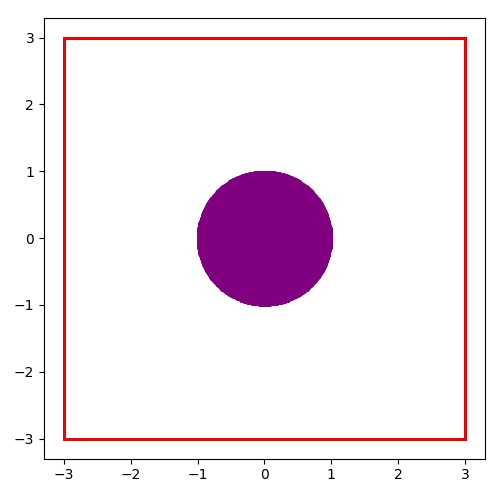

In [44]:


fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
    
plotRegions(regions, axis[0,0], plotFluid = True, plotParticles = True)
axis[0,0].set_aspect('equal', adjustable='box')

rectangle = plt.Rectangle((domain.min[0].cpu().numpy(), domain.min[1].cpu().numpy()), domain.max[0].cpu().numpy() - domain.min[0].cpu().numpy(), domain.max[1].cpu().numpy() - domain.min[1].cpu().numpy(), fill=False, color='black', lw=2)
axis[0,0].add_patch(rectangle)

rectangleInterior = plt.Rectangle((interiorDomain.min[0].cpu().numpy(), interiorDomain.min[1].cpu().numpy()), interiorDomain.max[0].cpu().numpy() - interiorDomain.min[0].cpu().numpy(), interiorDomain.max[1].cpu().numpy() - interiorDomain.min[1].cpu().numpy(), fill=False, color='red', lw=2)
axis[0,0].add_patch(rectangleInterior)

fig.tight_layout()




In [45]:
from sphMath.sampling import sampleDivergenceFreeNoise
import numpy as np

particleState, config, rigidBodies = initializeSimulation(scheme, config, regions)

u_mag = 1
k = np.pi


particleState.velocities[:,0] = A * particleState.positions[:,0]
particleState.velocities[:,1] = -A * particleState.positions[:,1]


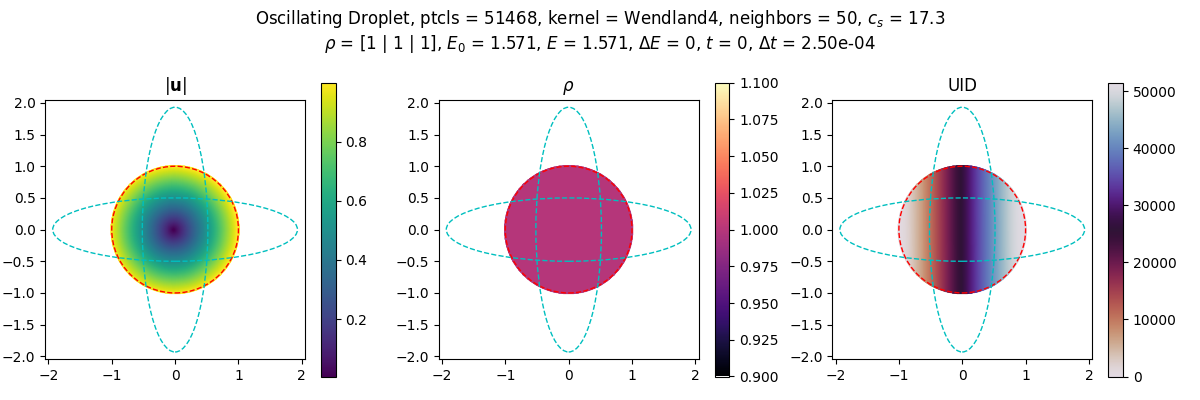

In [46]:
## Setup simulation, everything after this should be the same for all examples
fig, axis, velocityPlot, densityPlot, uidPlot, particleSystem, dt, initialKineticEnergy, initialPotentialEnergy, initialEnergy = setupExampleSimulation(simulationName, scheme, particleState, config, regions, stacked = 'horizontal', figsize = (12, 4))
import matplotlib.patches as patches
for ax in axis.flatten():
    initialElipse = patches.Ellipse((0,0), 2*R, 2*R, fill = False, edgecolor = 'r', linewidth = 1, linestyle = '--')#.set_clip_box(axis['A'].bbox)
    maxWidthElipse = patches.Ellipse((0,0), 1.931843 * 2*R, R, fill = False, edgecolor = 'c', linewidth = 1, linestyle = '--')#.set_clip_box(axis['A'].bbox)
    maxHeightElipse = patches.Ellipse((0,0), 2 / 1.931843 * R, 1.931843 * 2 * R, fill = False, edgecolor = 'c', linewidth = 1, linestyle = '--')#.set_clip_box(axis['A'].bbox)
    ax.add_patch(initialElipse)
    ax.add_patch(maxWidthElipse)
    ax.add_patch(maxHeightElipse)
for ax in axis.flatten():
    ax.set_xlim(-2.05*R, 2.05*R)
    ax.set_ylim(-2.05*R, 2.05*R)

imagePrefix = f'./images/{exportName}/'
os.makedirs(imagePrefix, exist_ok = True)
fig.savefig(f'{imagePrefix}frame_{0:05d}.png', dpi = 100)


In [47]:
states = []
for i in (tq:=tqdm(range(timesteps))):
    particleSystem, currentState, updates = integrationScheme.function(particleSystem, dt, simulator, config, priorStep = particleSystem.priorStep, verbose = False)

    rhoMin = particleSystem.systemState.densities.min().detach().cpu().item() / config['fluid']['rho0']
    rhoMean = particleSystem.systemState.densities.mean().detach().cpu().item() / config['fluid']['rho0']
    rhoMax = particleSystem.systemState.densities.max().detach().cpu().item() / config['fluid']['rho0']

    kineticEnergy = 0.5 * particleSystem.systemState.masses / config['fluid']['rho0'] * particleSystem.systemState.densities * torch.linalg.norm(particleSystem.systemState.velocities, dim = -1)**2
    potentialEnergy = None
    if config['gravity']['active']:
        if 'mode' in config['gravity'] and config['gravity']['mode'] == 'potential':
            B = config['gravity']['magnitude']
            potentialEnergy = 0.5 * B**2 * particleSystem.systemState.masses / config['fluid']['rho0'] * particleSystem.systemState.densities * torch.linalg.norm(particleSystem.systemState.positions, dim = -1)**2
            
    combinedEnergy = kineticEnergy + potentialEnergy if potentialEnergy is not None else kineticEnergy
    totalInitialEnergy = (initialEnergy).sum().detach().cpu().item()
    totalEnergy = (combinedEnergy).sum().detach().cpu().item()

    states.append([rhoMin, rhoMean, rhoMax, totalInitialEnergy, totalEnergy, totalEnergy - totalInitialEnergy, particleSystem.t, dt, particleSystem.systemState.positions[:,0].min().item(), particleSystem.systemState.positions[:,0].max().item(), particleSystem.systemState.positions[:,1].min().item(), particleSystem.systemState.positions[:,1].max().item()])

    if i % plotInterval == plotInterval - 1 or i == timesteps - 1:


        fig.suptitle(f'{simulationName}, ptcls = {particleSystem.systemState.positions.shape[0]}, kernel = {config["kernel"].name}, neighbors = {config["targetNeighbors"]:.2g}, $c_s$ = {config["fluid"]["c_s"]:.1f}\n$\\rho$ = [{rhoMin:.4g} | {rhoMean:.4g} | {rhoMax:.4g}], $E_0$ = {totalInitialEnergy:.4g}, $E$ = {totalEnergy:.4g}, $\\Delta E$ = {totalEnergy - totalInitialEnergy:.4g}, $t$ = {particleSystem.t:.4g}, $\Delta t$ = {dt:.2e}')
        updatePlot(velocityPlot, particleSystem.systemState, particleSystem.systemState.velocities)
        updatePlot(densityPlot, particleSystem.systemState, particleSystem.systemState.densities)
        updatePlot(uidPlot, particleSystem.systemState, particleSystem.systemState.UIDs)
        # if plotCallbackFn is not None:
            # plotCallbackFn(fig, axis, particleSystem, i)
        for ax in axis.flatten():
            ax.set_xlim(-2.05*R, 2.05*R)
            ax.set_ylim(-2.05*R, 2.05*R)

        fig.canvas.draw()
        fig.canvas.flush_events()
        fig.savefig(f'{imagePrefix}frame_{i:05d}.png', dpi = 200)

        # states.append([rhoMin, rhoMean, rhoMax, totalInitialEnergy, totalEnergy, totalEnergy - totalInitialEnergy, particleSystem.t, dt])

  0%|          | 0/19308 [00:00<?, ?it/s]

Namespace EOS not found in config. Setting type to isoThermal
Key kappa not found in config["EOS"]. Setting kappa to 1.3
Key polytropicExponent not found in config["EOS"]. Setting polytropicExponent to 7
Key gas_constant not found in config["EOS"]. Setting gas_constant to 8.314
Key molarMass not found in config["EOS"]. Setting molarMass to 0.02897
Key surfaceDetection not found in config["surfaceDetection"]. Setting surfaceDetection to Barecasco
Key normalScheme not found in config["surfaceDetection"]. Setting normalScheme to Lambda
Key colorSurfaceThreshold not found in config["surfaceDetection"]. Setting colorSurfaceThreshold to 1.5
Key colorGradientSurfaceThreshold not found in config["surfaceDetection"]. Setting colorGradientSurfaceThreshold to 10.0
Key barecascoThreshold not found in config["surfaceDetection"]. Setting barecascoThreshold to 1.0471975511965976
Key expansionIters not found in config["surfaceDetection"]. Setting expansionIters to 1
Key delta not found in config["diff

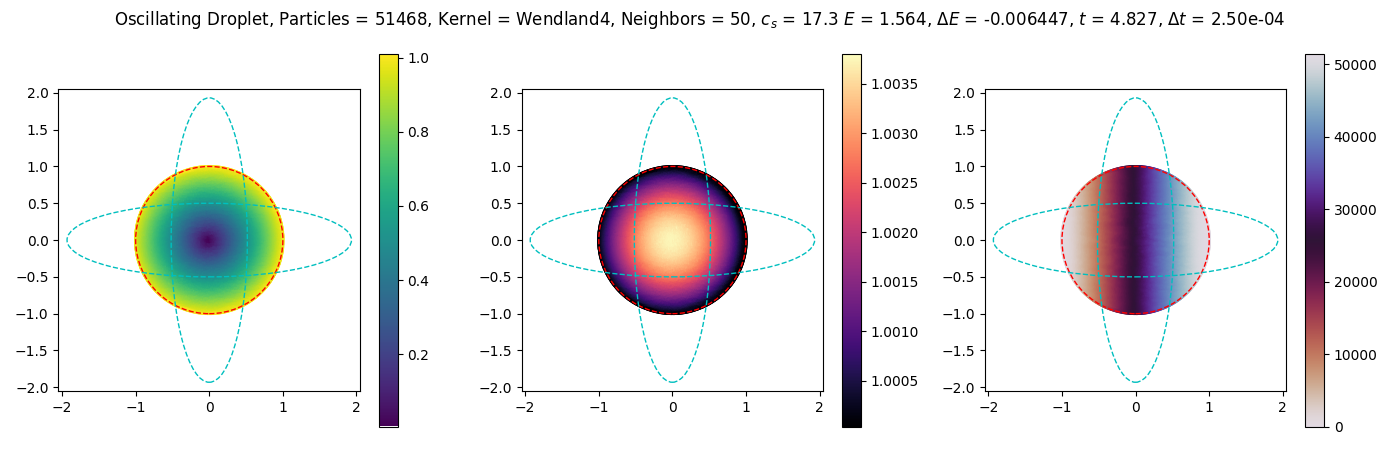

In [48]:
fig, axis = plt.subplots(1, 3, figsize=(14, 4.5), squeeze=False)

axes = axis.flatten()
velocityPlot = visualizeParticles(fig, axes[0], 
            particles = particleSystem.systemState, 
            domain = config['domain'], 
            quantity = particleSystem.systemState.velocities, 
            which = 'fluid',
            mapping = 'L2',
            cmap = 'viridis',
            visualizeBoth=False,
            kernel = config['kernel'],
            plotDomain = False,
            gridVisualization=False, markerSize=2, streamLines=False)

densityPlot = visualizeParticles(fig, axes[1],
            particles = particleSystem.systemState, 
            domain = config['domain'], 
            quantity = particleSystem.systemState.densities, 
            which = 'both',
            # operation = 'curl',
            mapping = '.y',
            cmap = 'magma',
            visualizeBoth=True,
            kernel = config['kernel'],
            plotDomain = False,
            gridVisualization=False, markerSize=2)

uidPlot = visualizeParticles(fig, axes[2],
            particles = particleSystem.systemState, 
            domain = config['domain'], 
            quantity = particleSystem.systemState.UIDs, 
            which = 'fluid',
            mapping = '.x',
            cmap = 'twilight_r',
            visualizeBoth=False,
            kernel = config['kernel'],
            plotDomain = False,
            gridVisualization=False, markerSize=2, streamLines=False)
for ax in axis.flatten():
    initialElipse = patches.Ellipse((0,0), 2*R, 2*R, fill = False, edgecolor = 'r', linewidth = 1, linestyle = '--')#.set_clip_box(axis['A'].bbox)
    maxWidthElipse = patches.Ellipse((0,0), 1.931843 * 2*R, R, fill = False, edgecolor = 'c', linewidth = 1, linestyle = '--')#.set_clip_box(axis['A'].bbox)
    maxHeightElipse = patches.Ellipse((0,0), 2 / 1.931843 * R, 1.931843 * 2 * R, fill = False, edgecolor = 'c', linewidth = 1, linestyle = '--')#.set_clip_box(axis['A'].bbox)
    ax.add_patch(initialElipse)
    ax.add_patch(maxWidthElipse)
    ax.add_patch(maxHeightElipse)
for ax in axis.flatten():
    ax.set_xlim(-2.05*R, 2.05*R)
    ax.set_ylim(-2.05*R, 2.05*R)
fig.suptitle(f'{simulationName}, Particles = {particleSystem.systemState.positions.shape[0]}, Kernel = {config["kernel"].name}, Neighbors = {config["targetNeighbors"]:.2g}, $c_s$ = {config["fluid"]["c_s"]:.1f} $E$ = {totalEnergy:.4g}, $\\Delta E$ = {totalEnergy - totalInitialEnergy:.4g}, $t$ = {particleSystem.t:.4g}, $\Delta t$ = {dt:.2e}')

fig.tight_layout()

fig.savefig(f'OscillatingDropletFinal.png', dpi = 200)


In [49]:
from inspect import getmembers, isclass
import matplotlib
import matplotlib.pyplot as plt
import numpy as np


def rasterize_and_save(fname, rasterize_list=None, fig=None, dpi=None,
                       savefig_kw={}):
    """Save a figure with raster and vector components
    This function lets you specify which objects to rasterize at the export
    stage, rather than within each plotting call. Rasterizing certain
    components of a complex figure can significantly reduce file size.
    Inputs
    ------
    fname : str
        Output filename with extension
    rasterize_list : list (or object)
        List of objects to rasterize (or a single object to rasterize)
    fig : matplotlib figure object
        Defaults to current figure
    dpi : int
        Resolution (dots per inch) for rasterizing
    savefig_kw : dict
        Extra keywords to pass to matplotlib.pyplot.savefig
    If rasterize_list is not specified, then all contour, pcolor, and
    collects objects (e.g., ``scatter, fill_between`` etc) will be
    rasterized
    Note: does not work correctly with round=True in Basemap
    Example
    -------
    Rasterize the contour, pcolor, and scatter plots, but not the line
    >>> import matplotlib.pyplot as plt
    >>> from numpy.random import random
    >>> X, Y, Z = random((9, 9)), random((9, 9)), random((9, 9))
    >>> fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(ncols=2, nrows=2)
    >>> cax1 = ax1.contourf(Z)
    >>> cax2 = ax2.scatter(X, Y, s=Z)
    >>> cax3 = ax3.pcolormesh(Z)
    >>> cax4 = ax4.plot(Z[:, 0])
    >>> rasterize_list = [cax1, cax2, cax3]
    >>> rasterize_and_save('out.svg', rasterize_list, fig=fig, dpi=300)
    """

    # Behave like pyplot and act on current figure if no figure is specified
    fig = plt.gcf() if fig is None else fig

    # Need to set_rasterization_zorder in order for rasterizing to work
    zorder = -5  # Somewhat arbitrary, just ensuring less than 0

    if rasterize_list is None:
        # Have a guess at stuff that should be rasterised
        types_to_raster = ['QuadMesh', 'Contour', 'collections']
        rasterize_list = []

        print("""
        No rasterize_list specified, so the following objects will
        be rasterized: """)
        # Get all axes, and then get objects within axes
        for ax in fig.get_axes():
            for item in ax.get_children():
                if any(x in str(item) for x in types_to_raster):
                    rasterize_list.append(item)
        print('\n'.join([str(x) for x in rasterize_list]))
    else:
        # Allow rasterize_list to be input as an object to rasterize
        if type(rasterize_list) != list:
            rasterize_list = [rasterize_list]

    for item in rasterize_list:

        # Whether or not plot is a contour plot is important
        is_contour = (isinstance(item, matplotlib.contour.QuadContourSet) or
                      isinstance(item, matplotlib.tri.TriContourSet))

        # Whether or not collection of lines
        # This is commented as we seldom want to rasterize lines
        # is_lines = isinstance(item, matplotlib.collections.LineCollection)

        # Whether or not current item is list of patches
        all_patch_types = tuple(
            x[1] for x in getmembers(matplotlib.patches, isclass))
        try:
            is_patch_list = isinstance(item[0], all_patch_types)
        except TypeError:
            is_patch_list = False

        # Convert to rasterized mode and then change zorder properties
        if is_contour:
            curr_ax = item.ax.axes
            curr_ax.set_rasterization_zorder(zorder)
            # For contour plots, need to set each part of the contour
            # collection individually
            for contour_level in item.collections:
                contour_level.set_zorder(zorder - 1)
                contour_level.set_rasterized(True)
        elif is_patch_list:
            # For list of patches, need to set zorder for each patch
            for patch in item:
                curr_ax = patch.axes
                curr_ax.set_rasterization_zorder(zorder)
                patch.set_zorder(zorder - 1)
                patch.set_rasterized(True)
        else:
            # For all other objects, we can just do it all at once
            curr_ax = item.axes
            curr_ax.set_rasterization_zorder(zorder)
            item.set_rasterized(True)
            item.set_zorder(zorder - 1)

    # dpi is a savefig keyword argument, but treat it as special since it is
    # important to this function
    if dpi is not None:
        savefig_kw['dpi'] = dpi

    # Save resulting figure
    fig.savefig(fname, **savefig_kw)


rasterize_and_save(f'Droplet_final.pdf', fig = fig)



        No rasterize_list specified, so the following objects will
        be rasterized: 


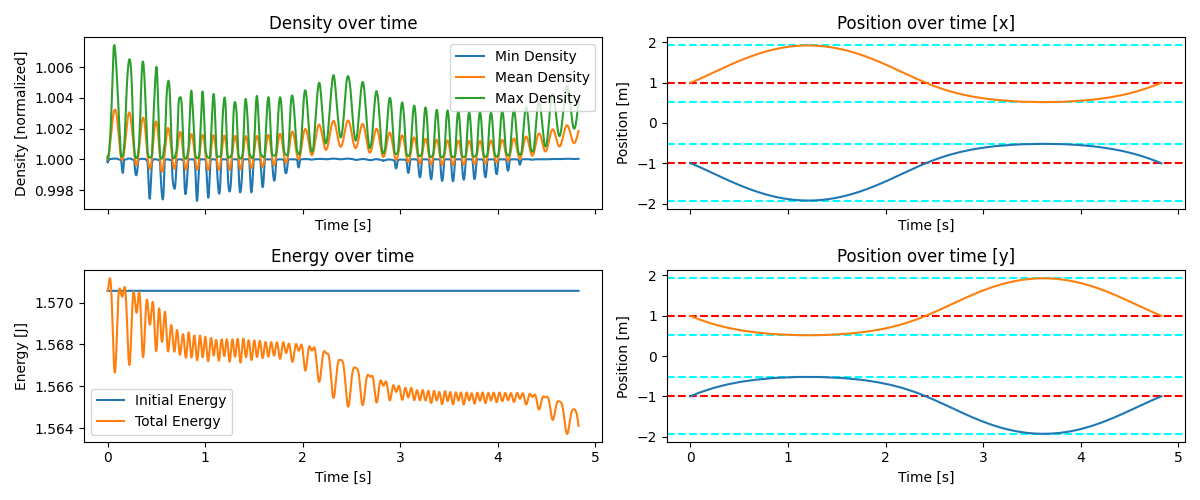

In [50]:
fig, axis = plt.subplots(2, 2, figsize=(12, 5), squeeze=False, sharex=True)

axis[0,0].plot([s[6].cpu().item() for s in states], [s[0] for s in states], label = 'Min Density')
axis[0,0].plot([s[6].cpu().item() for s in states], [s[1] for s in states], label = 'Mean Density')
axis[0,0].plot([s[6].cpu().item() for s in states], [s[2] for s in states], label = 'Max Density')
axis[0,0].set_xlabel('Time [s]')
axis[0,0].set_ylabel('Density [normalized]')
axis[0,0].set_title('Density over time')
axis[0,0].legend()

axis[1,0].plot([s[6].cpu().item() for s in states], [s[3] for s in states], label = 'Initial Energy')
axis[1,0].plot([s[6].cpu().item() for s in states], [s[4] for s in states], label = 'Total Energy')
# axis[1,0].plot([s[6].cpu().item() for s in states], [s[5] for s in states], label = 'Energy Difference')
axis[1,0].set_xlabel('Time [s]')
axis[1,0].set_ylabel('Energy [J]')
axis[1,0].set_title('Energy over time')
axis[1,0].legend()

# axis[2,0].plot([s[6].cpu().item() for s in states], [s[7] for s in states], label = 'Timestep')
# axis[2,0].set_xlabel('Time [s]')
# axis[2,0].set_ylabel('Timestep [s]')
# axis[2,0].set_title('Timestep over time')
# axis[2,0].legend()      

# axis[0,1].plot([s[6].cpu().item() for s in states], [s[10] for s in states], label = 'Min Y')
# axis[0,1].plot([s[6].cpu().item() for s in states], [s[11] for s in states], label = 'Max Y')

aspectRatio = 1.931843
axis[0,1].axhline(-R, color='red', linestyle='--', label='Initial Min X')
axis[0,1].axhline(R, color='red', linestyle='--', label='Initial Max X')
axis[0,1].axhline(-R / 1.931843, color='cyan', linestyle='--', label='Max Min Y')
axis[0,1].axhline(R / 1.931843, color='cyan', linestyle='--', label='Max Max Y')
axis[0,1].axhline(-aspectRatio * R, color='cyan', linestyle='--', label='Max Min X')
axis[0,1].axhline(aspectRatio * R, color='cyan', linestyle='--', label='Max Max X')
axis[0,1].plot([s[6].cpu().item() for s in states], [s[8] for s in states], label = 'Min X')
axis[0,1].plot([s[6].cpu().item() for s in states], [s[9] for s in states], label = 'Max X')
axis[0,1].set_xlabel('Time [s]')
axis[0,1].set_ylabel('Position [m]')
axis[0,1].set_title('Position over time [x]')

axis[1,1].axhline(-R, color='red', linestyle='--', label='Initial Min X')
axis[1,1].axhline(R, color='red', linestyle='--', label='Initial Max X')
axis[1,1].axhline(-R / 1.931843, color='cyan', linestyle='--', label='Max Min Y')
axis[1,1].axhline(R / 1.931843, color='cyan', linestyle='--', label='Max Max Y')
axis[1,1].axhline(-aspectRatio * R, color='cyan', linestyle='--', label='Max Min X')
axis[1,1].axhline(aspectRatio * R, color='cyan', linestyle='--', label='Max Max X') 
axis[1,1].plot([s[6].cpu().item() for s in states], [s[10] for s in states], label = 'Min Y')
axis[1,1].plot([s[6].cpu().item() for s in states], [s[11] for s in states], label = 'Max Y')
axis[1,1].set_xlabel('Time [s]')
axis[1,1].set_ylabel('Position [m]')
axis[1,1].set_title('Position over time [y]')
fig.tight_layout()

fig.savefig(f'EnergyOscillating.pdf', dpi = 200)

# axis[0,1].legend()

In [51]:
states[-1][4] / states[-1][3]

0.9958951556455594

In [ ]:
def plotCallbackFn(fig, axis, particleSystem, i):
    for ax in axis.flatten():
        ax.set_xlim(-2.05*R, 2.05*R)
        ax.set_ylim(-2.05*R, 2.05*R)

# runSimulation(simulationName, particleSystem, integrationScheme, simulator, timesteps, dt, config, fig, axis, velocityPlot, densityPlot, uidPlot, initialEnergy, imagePrefix, plotInterval, plotCallbackFn = plotCallbackFn )

# print('Finished simulation')
# ## Post process simulation
# postProcess(imagePrefix, fps, timesteps, exportName)
# ## Cleanup

  0%|          | 0/9654 [00:00<?, ?it/s]

Namespace EOS not found in config. Setting type to isoThermal
Key kappa not found in config["EOS"]. Setting kappa to 1.3
Key polytropicExponent not found in config["EOS"]. Setting polytropicExponent to 7
Key gas_constant not found in config["EOS"]. Setting gas_constant to 8.314
Key molarMass not found in config["EOS"]. Setting molarMass to 0.02897
Key surfaceDetection not found in config["surfaceDetection"]. Setting surfaceDetection to Barecasco
Key normalScheme not found in config["surfaceDetection"]. Setting normalScheme to Lambda
Key colorSurfaceThreshold not found in config["surfaceDetection"]. Setting colorSurfaceThreshold to 1.5
Key colorGradientSurfaceThreshold not found in config["surfaceDetection"]. Setting colorGradientSurfaceThreshold to 10.0
Key barecascoThreshold not found in config["surfaceDetection"]. Setting barecascoThreshold to 1.0471975511965976
Key expansionIters not found in config["surfaceDetection"]. Setting expansionIters to 1
Key delta not found in config["diff